Dynamics Structure in the Solar System
</p>
<em>Condition for Paun structure near Earth</em>
</p>
Condition

webstie for time conversion
https://heasarc.gsfc.nasa.gov/cgi-bin/Tools/xTime/xTime.pl?time_in_i=&time_in_c=&time_in_d=&time_in_j=&time_in_m=60473.27430556016&time_in_sf=&time_in_wf=&time_in_ii=&time_in_sl=&time_in_sni=&time_in_snu=&time_in_s=&time_in_h=&time_in_sz=&time_in_ss=&time_in_sn=&time_in_sxr=&timesys_in=u&timesys_out=u&apply_clock_offset=yes

In [1]:
# sim is simulation class from rebound
# filename is the rebound simulation environment setup file
# filename,MJD_model,SMA,ECC,MJD_model,MA_config in radians
# record minimum distance to Jupiter
def MEGNO_from_rebound(filename,MJD_model,SMA,ECC,INC,RAAN,AOP,MA,**kwargs):
    sim = rebound.Simulation(filename)
    # Name, a, e, i, long. node, arg. peric., mean anomaly
    # Test Particle
    sim.add(primary=sim.particles[0], a=SMA, e=ECC, inc=INC, Omega=RAAN, omega=AOP, M=MA)
    #   plotting orbit
    #    for orbit in sim.calculate_orbits(primary=sim.particles[0]):
    #        print(orbit)
    #        print("M =", orbit.M)
    
    # integration time parameters
    tspan = kwargs['tspan']
    Long_term_year = tspan # 1 year is 1 year on Earth
    year = 2.*np.pi # One year in units where G=1
    time_propagate = Long_term_year*year
    
    # integrator parameters
    sim.integrator = kwargs['simintegrator']
    sim.dt = kwargs['simdt'] # we're working in units where 1 year = 2*pi
    sim.ri_ias15.min_dt = kwargs['sim_ias15dt'] # ensure that close encounters do not stall the integration
    sim.ri_ias15.epsilon = kwargs['epsilon'] # control accuracy for ias15
    
    sim.move_to_com()        # We always move to the center of momentum frame before an integration
    ps = sim.particles       # ps is now an array of pointers and will change as the simulation runs
    
    #sim.status() # show status in Cartesian coordinate
    sim.init_megno(seed=0)
    sim.exit_max_distance = 20.
    
    try:
        sim.integrate(time_propagate, exact_finish_time=0) # integrate for time_propagate, integrating to the nearest
        #timestep for each output to keep the timestep constant and preserve WHFast's symplectic nature
        megno = sim.megno() 
        return megno
    except rebound.Escape:
        return 6969. # At least one particle got ejected, returning large MEGNO specifically 6969.

In [2]:
!pip install rebound matplotlib julian numpy pandas joblib

In [3]:
import rebound
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import datetime, julian
from math import degrees, radians
from solar_constant import *
import multiprocessing
from joblib import Parallel, delayed
from pathlib import Path
import time,os, signal, json

In [4]:
folder = "Data/"
# date
date = "2023-01-07 00:00:00" # time from small body data base
date_info = datetime.datetime.strptime(date,"%Y-%m-%d %H:%M:%S")
date_info_day=date_info.strftime("%Y-%m-%d")
MJD_model = julian.to_jd(date_info,fmt='mjd')
print(MJD_model)

59951.0


In [5]:
# rebound simulation
rebound.horizons.SSL_CONTEXT = 'unverified'
sim = rebound.Simulation()
sim.add('Sun',date = date)
sim.add('Luna',primary=sim.particles[0])
sim.add('Geo',primary=sim.particles[0])

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Luna'... 
Found: Moon (301) (chosen from query 'Luna')
Searching NASA Horizons for 'Geo'... 
Found: Earth (399) (chosen from query 'Geo')


In [6]:
# save to binary setup file
simfile = f"Helio_SEM_{MJD_model}.bin"
# sim.save_to_file(simfile)
sim = rebound.Simulation(simfile)
print(f'{sim.units}')
# start_time = time.time()

/Users/woodywu/anaconda3/envs/XD_LDDS/lib/python3.11/site-packages/rebound/simulation.py:153: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)


{'length': 'au', 'mass': 'msun', 'time': 'yr2pi'}


In [7]:
# condition from Horizons in AU, deg
a_t, e_t, i_t = 0.9, 0.01, 5
Om_t, w_t, M_t = 10,20,30
sim.add(primary=sim.particles[0],a=a_t,e=e_t,inc=radians(i_t),Omega=radians(Om_t),omega=radians(w_t),M=radians(M_t))
particle = sim.particles[-1]
particle_orbit = particle.orbit(primary=sim.particles[0])
print(particle_orbit,'\n',particle_orbit.M)

<rebound.Orbit instance, a=0.9000000000000004 e=0.010000000000000292 inc=0.08726646259971634 Omega=0.17453292519943256 omega=0.34906585039888327 f=0.5337079924213386> 
 0.5235987755982698


---------------------------------
REBOUND version:     	4.4.11
REBOUND built on:    	Nov 13 2025 14:50:42
Number of particles: 	4
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x11385e720, m=0.9999999999950272 x=-0.009049240250429191 y=4.1006107715160495e-05 z=0.00021046412599197997 vx=5.946345859346074e-05 vy=-0.0005222446392674234 vz=2.896858839220246e-06>
<rebound.particle.Particle object at 0x18a748c20, m=3.694303350091508e-08 x=-0.28223416531329765 y=0.9474578064440712 z=0.00037692542831995536 vx=-1.008178206232188 vy=-0.2903032982561152 vz=0.0012165351943675764>
<rebound.particle.Particle object at 0x11385e720, m=3.0034896154502038e-06 x=-0.28146782717521757 y=0.9448645708371544 z=0.00016032685113079884 vx=-0.9767840902575164 vy=-0.2812891628351343 vz=7.834403708854549e-06>
<rebound.particle.Particle object at 0x18a748c20, m=0.0 x=0.42968650849518936 y=

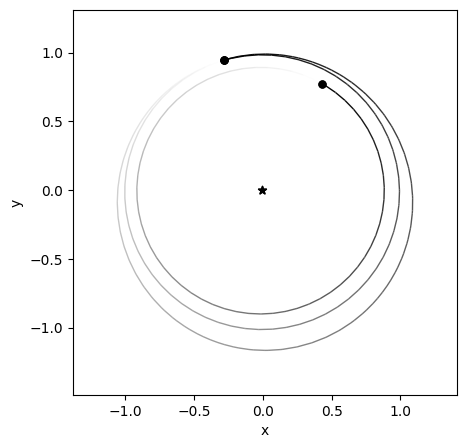

In [15]:
sim.status()
%matplotlib inline
fig = rebound.OrbitPlot(sim) #,slices=0.5,orbit_type="solid",xlim=[-1.,1.],ylim=[-1.1,-0.9])

In [9]:
# rebound propagation detail
simintegrator = 'ias15' #'mercurius'
simdt = 0.0001 # 2pi is 1 year, time follows equation t = simdt/(2*pi)*1*365.25 (day)
sim_ias15dt = 0 # ensure that close encounters do not stall the integration
epsilon = 1e-8 # control accuracy for ias15
tspan = 20 # year, 1 year is 1 year on Earth 365.25 solar days/earth days
No_output = 10000
rb_detail = {'simintegrator':simintegrator, 'simdt':simdt, 'sim_ias15dt':sim_ias15dt,
            'epsilon':epsilon, 'No_output':No_output, 'tspan':tspan}


In [10]:
moon_orbit = sim.particles[1].orbit(primary=sim.particles[0])  # Get Moon's orbital elements
moon_inc = moon_orbit.inc  # Moon's inclination in radians
print(f"Moon's inclination: {degrees(moon_inc):.2f} degrees")
earth_orbit = sim.particles[2].orbit(primary=sim.particles[0])  # Get Earth's orbital elements (particles[2] is Earth)
earth_inc = earth_orbit.inc  # Earth's inclination in radians
print(f"Earth's inclination: {degrees(earth_inc):.2f} degrees")

Moon's inclination: 0.07 degrees
Earth's inclination: 0.00 degrees


In [ ]:
i_test = earth_orbit.inc # Use Earth's inclination for the test particle
INC_deg, RAAN_deg, AOP_deg, MA_deg = degrees(i_test), 0, 0, 90 # mean longitude = RAAN + AOP + MA 90 is paun
INC, RAAN, AOP, MA = radians(INC_deg), radians(RAAN_deg), radians(AOP_deg), radians(MA_deg)

SMA_min, SMA_max = 0.96, 1.04 #AU
ECC_min, ECC_max = 0.01, 0.9
No_steps_SMA = 300#5#00 #250#0
No_steps_ECC = 80#8#0 #40#0
SMA_linspace = np.linspace(SMA_min,SMA_max,No_steps_SMA) 
ECC_linspace = np.linspace(ECC_min,ECC_max,No_steps_ECC) 
SMA_grid,ECC_grid = np.meshgrid(SMA_linspace,ECC_linspace)

# flatten for calculation
SMA_flatlist = SMA_grid.flatten().tolist()
ECC_flatlist = ECC_grid.flatten().tolist()

# Count number of cores
numCores = multiprocessing.cpu_count()

start_time = time.time()
megno_flatlist = Parallel(n_jobs = numCores)(delayed(MEGNO_from_rebound)(simfile,MJD_model,SMA,ECC,INC,RAAN,AOP,MA,**rb_detail) for SMA,ECC in zip(SMA_flatlist,ECC_flatlist))
print(time.time()-start_time)

249.58977508544922


In [30]:
df = pd.DataFrame(list(zip(SMA_flatlist,ECC_flatlist,megno_flatlist)),columns =['SMA', 'ECC', 'MEGNO'])
# df.to_csv(f'Data/MEGNO_{date}_span{tspan}_SMA{SMA_min_Re}_{SMA_max_Re}_{No_steps_SMA}steps_ECC{ECC_min}_{ECC_max}_{No_steps_ECC}steps.csv')
# TP's universal ICs
df_IC = pd.DataFrame(list([date_info_day,INC,RAAN,AOP,MA]),index=['date','INC','RAAN','AOP','M'])
# df_IC.to_csv(f'Data/IC_{date_info_day}_span{tspan}_SMA{SMA_min_Re}_{SMA_min_Re}_{No_steps_SMA}steps_ECC{ECC_min}_{ECC_max}_{No_steps_ECC}steps.csv')

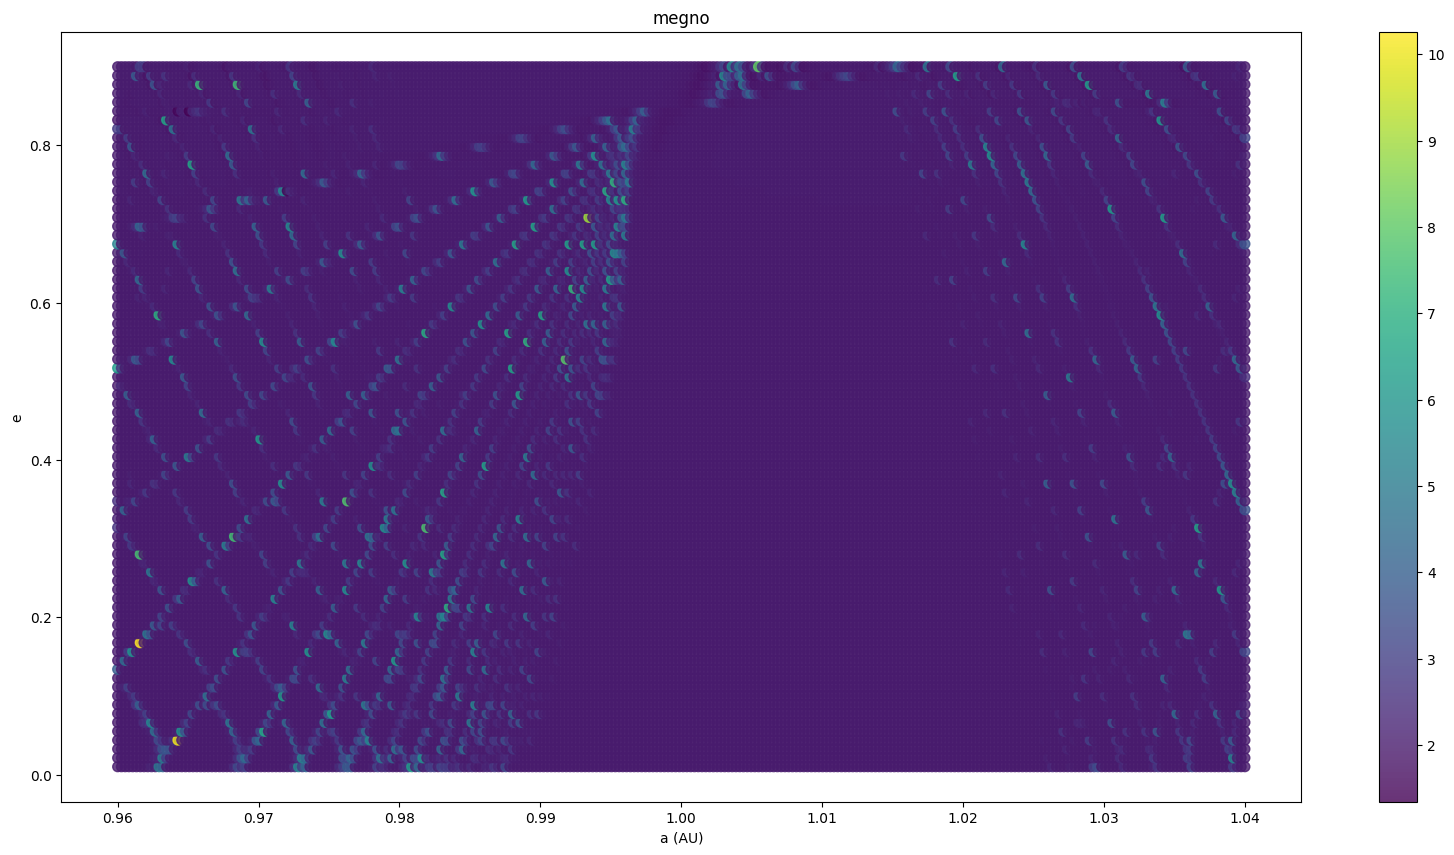

In [31]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=[20,10])
x = SMA_flatlist 
y = ECC_flatlist
# color = [np.log(i) for i in megno_flatlist]
color = megno_flatlist
plt.scatter(x, y, c=color, alpha=0.8, s=50)
plt.title('megno')
plt.xlabel('a (AU)')
plt.ylabel('e')
plt.colorbar()
# fig.savefig("graph.pdf", bbox_inches='tight')
plt.show()

## Chunk running version

In [33]:
i_test = earth_orbit.inc # Use Earth's inclination for the test particle
INC_deg, RAAN_deg, AOP_deg, MA_deg = degrees(i_test), 0, 0, 90 # mean longitude = RAAN + AOP + MA 90 is paun
INC, RAAN, AOP, MA = radians(INC_deg), radians(RAAN_deg), radians(AOP_deg), radians(MA_deg)

SMA_min, SMA_max = 0.96, 1.04 #AU
ECC_min, ECC_max = 0.01, 0.9
No_steps_SMA = 300#5#00 #250#0
No_steps_ECC = 80#40#0
# ==== your existing grid ====
SMA_linspace = np.linspace(SMA_min, SMA_max, No_steps_SMA)
ECC_linspace = np.linspace(ECC_min, ECC_max, No_steps_ECC)
SMA_grid, ECC_grid = np.meshgrid(SMA_linspace, ECC_linspace)

# make a stable index for each (SMA,ECC) pair
pairs = [(idx, float(SMA), float(ECC))
         for idx, (SMA, ECC) in enumerate(zip(SMA_grid.ravel(), ECC_grid.ravel()))]
total = len(pairs)

# ==== output paths ====
outdir = Path("Data")
outdir.mkdir(exist_ok=True)
outfile = outdir / f"MEGNO_{date}_MA{MA}_span{tspan}_SMA{SMA_min}_{SMA_max}_{No_steps_SMA}steps_ECC{ECC_min}_{ECC_max}_{No_steps_ECC}steps.csv"
done_json = outdir / f"MEGNO_{date}_MA{MA}_span{tspan}_done_indices.json"

# write IC file once (if you like keeping it separate)
icfile = outdir / f"IC_{date_info_day}_MA{MA}_span{tspan}_SMA{SMA_min}_{SMA_max}_{No_steps_SMA}steps_ECC{ECC_min}_{ECC_max}_{No_steps_ECC}steps.csv"
if not icfile.exists():
    df_IC = pd.DataFrame(
        {"value":[date_info_day, INC, RAAN, AOP, MA]},
        index=["date","INC","RAAN","AOP","M"]
    )
    df_IC.to_csv(icfile)

# ==== load 'done' set if resuming ====
done = set()
if outfile.exists():
    try:
        # prefer indexing by 'idx' column if present
        existing = pd.read_csv(outfile, usecols=["idx"])
        done.update(existing["idx"].astype(int).tolist())
    except Exception:
        # fallback: infer by SMA/ECC (rounded to avoid fp noise)
        existing = pd.read_csv(outfile, usecols=["SMA","ECC"])
        seen = set(zip(np.round(existing["SMA"],12), np.round(existing["ECC"],12)))
        for i,(idx,SMA,ECC) in enumerate(pairs):
            if (round(SMA,12), round(ECC,12)) in seen:
                done.add(idx)

# also merge persisted done_json if present
if done_json.exists():
    try:
        done |= set(json.loads(done_json.read_text()))
    except Exception:
        pass

pending = [(i,s,e) for (i,s,e) in pairs if i not in done]
print(f"Total {total} | Done {len(done)} | Pending {len(pending)}")

# ==== graceful termination handling ====
terminate = {"flag": False}
def _sigterm(signum, frame): terminate["flag"] = True
signal.signal(getattr(signal, "SIGTERM", 15), _sigterm)

# ==== compute wrapper ====
def compute_one(idx, SMA, ECC):
    try:
        val = MEGNO_from_rebound(simfile, MJD_model, SMA, ECC, INC, RAAN, AOP, MA, **rb_detail)
        return {"idx": idx, "SMA": SMA, "ECC": ECC, "MEGNO": float(val),
                "INC": INC, "RAAN": RAAN, "AOP": AOP, "MA": MA}
    except Exception as ex:
        # keep the row with NaN + error for easy re-run filtering
        return {"idx": idx, "SMA": SMA, "ECC": ECC, "MEGNO": np.nan,
                "INC": INC, "RAAN": RAAN, "AOP": AOP, "MA": MA, "error": str(ex)}

# ==== execution params ====
numCores = max(1, multiprocessing.cpu_count() - 1)
batch_size = 48  # tune to your runtime per point

# write header if file new
write_header = not outfile.exists()

# ==== main loop ====
t0 = time.time()
for b0 in range(0, len(pending), batch_size):
    batch = pending[b0:b0+batch_size]
    results = Parallel(n_jobs=numCores, prefer="processes", batch_size="auto")(
        delayed(compute_one)(i, s, e) for (i, s, e) in batch
    )

    df = pd.DataFrame(results, columns=["idx","SMA","ECC","MEGNO","INC","RAAN","AOP","MA","error"])
    # append incrementally
    df.to_csv(outfile, mode="a", header=write_header, index=False)
    write_header = False

    # persist 'done' (only successes count as done; or keep all to avoid rework—choose one)
    for r in results:
        if np.isfinite(r.get("MEGNO", np.nan)):
            done.add(r["idx"])
    done_json.write_text(json.dumps(sorted(done)))

    print(f"Checkpointed {len(done)}/{total} in {time.time()-t0:.1f}s")

    if terminate["flag"]:
        print("Received SIGTERM: exiting cleanly after checkpoint.")
        break

print("Run finished (or cleanly stopped).")

Total 24000 | Done 0 | Pending 24000


/Users/woodywu/anaconda3/envs/XD_LDDS/lib/python3.11/site-packages/rebound/simulation.py:153: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/woodywu/anaconda3/envs/XD_LDDS/lib/python3.11/site-packages/rebound/simulation.py:153: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/woodywu/anaconda3/envs/XD_LDDS/lib/python3.11/site-packages/rebound/simulation.py:153: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/woodywu/anaconda3/envs/XD_LDDS/lib/python3.11/site-packages/rebound/simulation.py:153: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/woodywu/anaconda3

Checkpointed 48/24000 in 0.9s
Checkpointed 96/24000 in 1.5s
Checkpointed 144/24000 in 2.1s
Checkpointed 192/24000 in 2.7s
Checkpointed 240/24000 in 3.3s
Checkpointed 288/24000 in 3.9s
Checkpointed 336/24000 in 4.4s
Checkpointed 384/24000 in 5.0s
Checkpointed 432/24000 in 5.6s
Checkpointed 480/24000 in 6.1s
Checkpointed 528/24000 in 6.7s
Checkpointed 576/24000 in 7.3s
Checkpointed 624/24000 in 7.8s
Checkpointed 672/24000 in 8.5s
Checkpointed 720/24000 in 9.1s
Checkpointed 768/24000 in 9.7s
Checkpointed 816/24000 in 10.2s
Checkpointed 864/24000 in 10.8s
Checkpointed 912/24000 in 11.4s
Checkpointed 960/24000 in 12.0s
Checkpointed 1008/24000 in 12.6s
Checkpointed 1056/24000 in 13.2s
Checkpointed 1104/24000 in 13.8s
Checkpointed 1152/24000 in 14.4s
Checkpointed 1200/24000 in 15.0s
Checkpointed 1248/24000 in 15.6s
Checkpointed 1296/24000 in 16.2s
Checkpointed 1344/24000 in 16.8s
Checkpointed 1392/24000 in 17.4s
Checkpointed 1440/24000 in 17.9s
Checkpointed 1488/24000 in 18.5s
Checkpointed 15

In [4]:
outfile = 'Data/MEGNO_2024-06-12 06:35:00_span12_SMA5_240_2500steps_ECC0.01_0.99_400steps.csv'

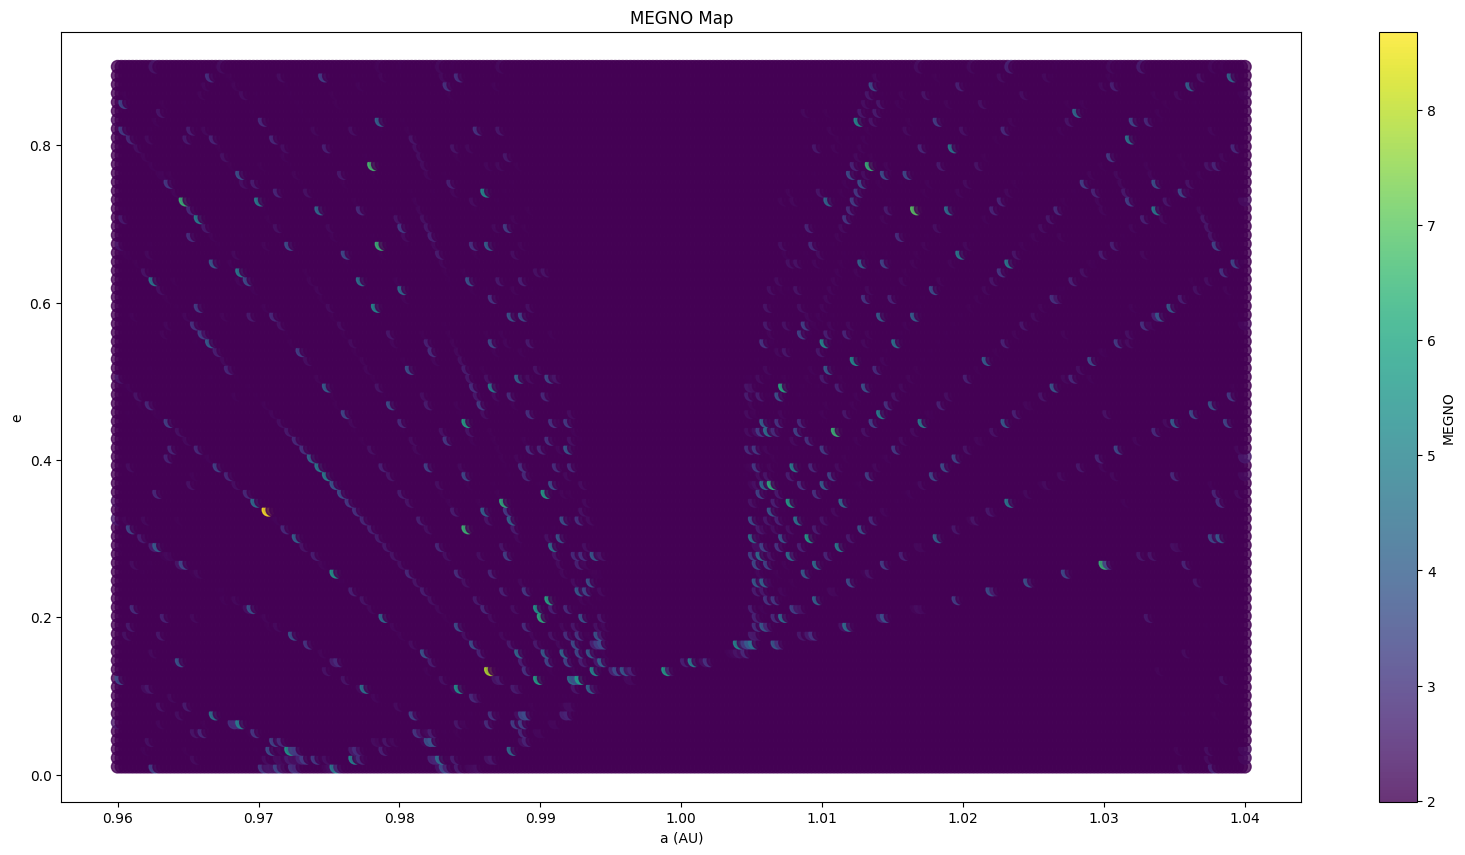

In [38]:
# load the accumulated results
df = pd.read_csv(outfile)   # same 'outfile' you used to save batches

# SMA in AU and ECC
x = df["SMA"]
y = df["ECC"]

# log color scale of MEGNO values
# color = np.log(df["MEGNO"])
color = df["MEGNO"]

fig, ax = plt.subplots(figsize=(20,10))
sc = ax.scatter(x, y, c=color, alpha=0.8, s=80, cmap="viridis")

ax.set_title("MEGNO Map")
ax.set_xlabel("a (AU)")
ax.set_ylabel("e")

cbar = plt.colorbar(sc, ax=ax)
# cbar.set_label("log(MEGNO)")
cbar.set_label("MEGNO")

# overlay your reference particle orbit if any

# fig.savefig("graph.pdf", bbox_inches="tight")
plt.show()

## Testing MEGNO Calculation

In [6]:
binfile = "CislunarSun_61264.73465277767.bin"  # example file
SMA_au, ECC, MEGNO_pre, = 4.67153289e-03, 5.57719298e-01, 3.64171627e+01,
INC_deg, Omega_deg, omega_deg, MA_deg = 5.27621738e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00
INC, RAAN, AOP, MA = np.radians(INC_deg), np.radians(Omega_deg), np.radians(omega_deg), np.radians(MA_deg)

date = "2026-08-12 17:37:54" # time from small body data base
date_info = datetime.datetime.strptime(date,"%Y-%m-%d %H:%M:%S")
date_info_day=date_info.strftime("%Y-%m-%d")
MJD_model = julian.to_jd(date_info,fmt='mjd')

# rebound propagation detail
simintegrator = 'ias15' #'mercurius'
simdt = 0.0001 # 2pi is 1 year, time follows equation t = simdt/(2*pi)*1*365.25 (day)
sim_ias15dt = 0 # ensure that close encounters do not stall the integration
epsilon = 1e-8 # control accuracy for ias15
tspan = 12 #10 #12 #8 #10 # 1 year is 1 year on Earth 365.25 solar days/earth days
No_output = 10000
rb_detail = {'simintegrator':simintegrator, 'simdt':simdt, 'sim_ias15dt':sim_ias15dt,
            'epsilon':epsilon, 'No_output':No_output, 'tspan':tspan}

megno_out = MEGNO_from_rebound(binfile,MJD_model,SMA_au,ECC,INC,RAAN,AOP,MA,**rb_detail)
megno_out



1.6307575826217333